# MATH2603 Lab — Preferential Attachment & the BA Model (Advanced)

**Theme (aligns with BA model / scale-free networks lecture):** growth + preferential attachment; degree distributions; power laws; extensions (nonlinear attachment, copying).

**What you will produce today:** a set of plots + short answers in Markdown cells (or your lab log).

> **Tip:** Run cells **top to bottom**. If you get errors like `NameError`, it usually means you skipped a cell.

---

## Learning outcomes
By the end of this lab, you should be able to:
1. Generate ER and BA networks and compare their degree distributions.
2. Explain (in words) why preferential attachment produces hubs.
3. Implement a simple BA-style generator yourself.
4. Explore **nonlinear preferential attachment** (\(k^\alpha\)) and interpret the effect of \(\alpha\).
5. Explore a **copying** mechanism as an alternative route to heavy-tailed degree distributions.
6. (Optional) Estimate a power-law exponent roughly and reflect on limitations.


## 0. Setup check (5–10 min)

Run the next cell. If you get `ModuleNotFoundError`, install the missing package (ask the instructor / use your environment manager).


In [3]:
%pip install -U numpy matplotlib networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 89.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 47.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 70.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 66.0 MB/s  0:00:00
   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/9 [numpy]]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━ 5/9 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress thi

In [4]:
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("networkx:", nx.__version__)


Python: 3.12.1
Platform: Linux-6.8.0-1044-azure-x86_64-with-glibc2.39
numpy: 2.4.2
matplotlib: 3.10.8
networkx: 3.6.1


## Helper functions (provided)

These functions keep the lab tidy:
- `plot_degree_hist`: histogram of degrees
- `plot_degree_loglog_counts`: log–log counts (not perfect, but good for intuition)
- `ccdf_loglog`: CCDF on log–log axes (often smoother than raw counts)


In [ ]:
def degrees_list(G):  #把图里的每个节点的度数收集成组，返回一堆（node，degree）
    return np.array([d for _, d in G.degree()], dtype=int)

def plot_degree_hist(deg, bins=30, title="Degree histogram"):
    plt.figure(figsize=(6,4))
    plt.hist(deg, bins=bins)
    plt.xlabel("degree k")
    plt.ylabel("count")
    plt.title(title)
    plt.show()

def plot_degree_loglog_counts(deg, title="Degree counts (log-log)"):
    # count occurrences of each degree value
    vals, counts = np.unique(deg, return_counts=True)
    plt.figure(figsize=(6,4))
    plt.loglog(vals, counts, "o")
    plt.xlabel("degree k")
    plt.ylabel("count")
    plt.title(title)
    plt.show()

def ccdf_loglog(deg, title="CCDF (log-log)"):
    # CCDF: P(K >= k)
    vals, counts = np.unique(deg, return_counts=True)
    N = counts.sum()
    # sort ascending by degree
    order = np.argsort(vals)
    vals = vals[order]
    counts = counts[order]
    # cumulative from the right
    ccdf = np.cumsum(counts[::-1])[::-1] / N
    plt.figure(figsize=(6,4))
    plt.loglog(vals, ccdf, "o")
    plt.xlabel("degree k")
    plt.ylabel("P(K ≥ k)")
    plt.title(title)
    plt.show()

def draw_graph_small(G, title="Graph", seed=0):
    # For small graphs only, otherwise it is too slow/cluttered
    plt.figure(figsize=(6,5))
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, node_size=300, with_labels=True)
    plt.title(title)
    plt.show()


## Part A — Warm-up: ER vs BA (basic → intuition)

### Task A1 (ER network)
Generate an Erdős–Rényi (ER) graph \(G(n,p)\) and inspect the degree distribution.

- ER typically has a degree distribution concentrated around its mean (approximately Poisson-like for large \(n\) with small \(p\)).
- Hubs are less extreme than in scale-free networks.

**Do:** Run the cell and look at the plots.


ER: n = 500 m = 2478
ER: mean degree = 9.912 max degree = 19


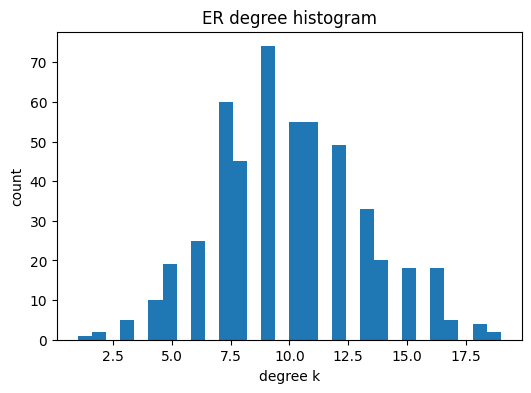

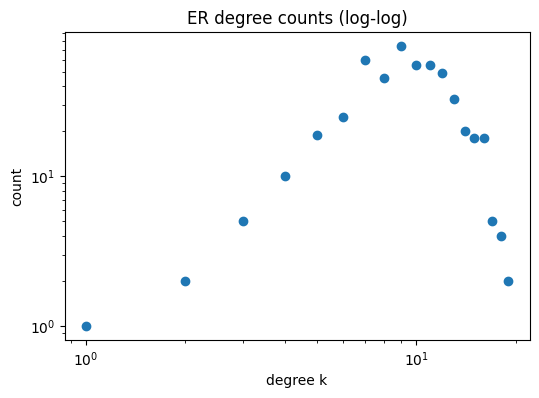

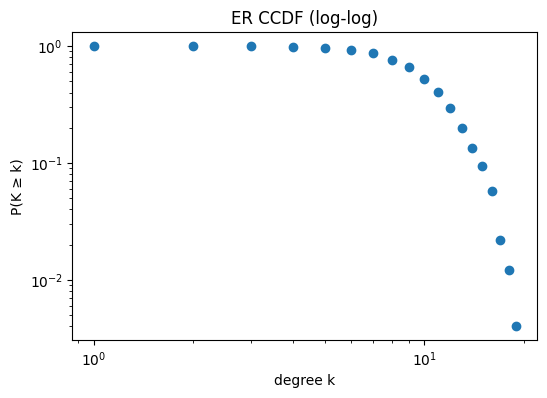

In [6]:
# Parameters (feel free to tweak)
n = 500
p = 0.02

G_er = nx.erdos_renyi_graph(n, p, seed=0)
deg_er = degrees_list(G_er)

print("ER: n =", G_er.number_of_nodes(), "m =", G_er.number_of_edges())
print("ER: mean degree =", deg_er.mean(), "max degree =", deg_er.max())

plot_degree_hist(deg_er, bins=30, title="ER degree histogram")
plot_degree_loglog_counts(deg_er, title="ER degree counts (log-log)")
ccdf_loglog(deg_er, title="ER CCDF (log-log)")


### Short answer (A1) — write 3–5 sentences

1. Describe the *shape* of the ER degree distribution (roughly symmetric? heavy-tailed?).  
ER 图的度分布大多集中在平均度附近，形状大致是“近似泊松/钟形”，整体比较对称，不是明显的长尾分布.  
n an ER G(n,p) graph, the degree distribution is typically concentrated around the mean, roughly Poisson-/bell-shaped and not strongly heavy-tailed.  

2. Did you observe very large hubs? Compare `max degree` to the mean.  
我没有观察到特别极端的 hub：平均度约为 (mean ≈ 9.912)，最大度约为 (max ≈ 19)，最大度只比均值大一些，没有“少数节点超级大”的现象。  
I did not observe very large hubs: the mean degree is 9.912 while the maximum degree is 19, so the maximum is only about 1.9× the mean.  

3. Why might ER be a poor model for networks like the web or social networks?  
因此 ER 往往不适合建模 web/社交网络：真实网络常有增长和**优先连接（富者愈富）**机制，会产生更强的长尾和显著 hub，而 ER 的独立同概率连边很难生成这些结构。  
This helps explain why ER can be a poor model for the web or social networks: real networks often involve growth and preferential attachment, producing heavy tails and prominent hubs that ER does not capture well.


### Task A2 (BA network)
Generate a Barabási–Albert (BA) graph with preferential attachment.

- BA tends to produce a **heavy-tailed** degree distribution and visible hubs.
- Parameter \(m\) = number of edges each new node adds.


BA: n = 500 m = 1491
BA: mean degree = 5.964 max degree = 74


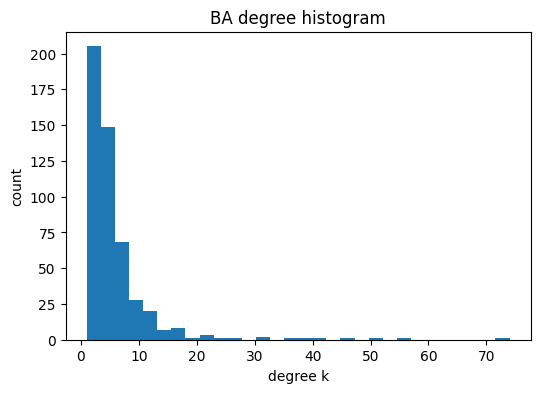

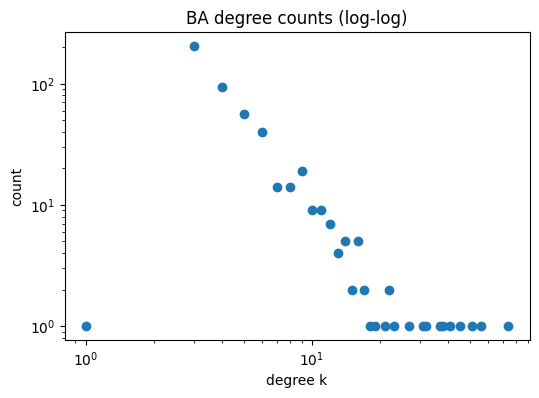

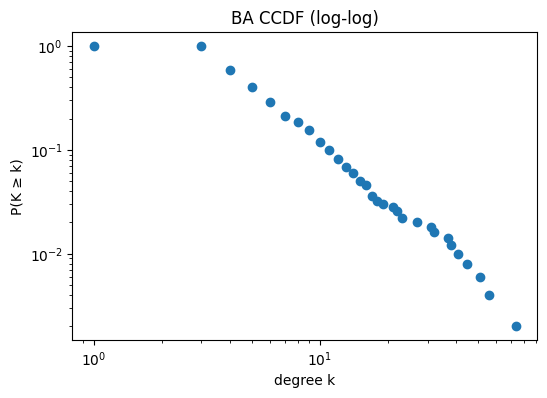

In [7]:
n = 500
m = 3

G_ba = nx.barabasi_albert_graph(n, m, seed=0)
deg_ba = degrees_list(G_ba)

print("BA: n =", G_ba.number_of_nodes(), "m =", G_ba.number_of_edges())
print("BA: mean degree =", deg_ba.mean(), "max degree =", deg_ba.max())

plot_degree_hist(deg_ba, bins=30, title="BA degree histogram")
plot_degree_loglog_counts(deg_ba, title="BA degree counts (log-log)")
ccdf_loglog(deg_ba, title="BA CCDF (log-log)")


### Short answer (A2) — write 4–6 sentences

1. Compare BA vs ER: which has bigger hubs, and how do you see this in the plots?  
BA has bigger hubs.  从直方图也能看到 BA 右侧尾巴更长、少数节点度特别高；ER 的度主要集中在均值附近，没有特别极端的节点。  

2. On the log–log plots, does BA says “closer to a straight line” than ER? What does that suggest?  
在 log-log 图（counts 或 CCDF）上，BA 的点更接近一条直线，而 ER 更弯/更快掉下去。这暗示 BA 更接近幂律（scale-free）分布，而 ER 更像泊松型集中分布。  
On the log–log plots (counts/CCDF), BA appears closer to a straight line than ER, while ER bends downward more strongly.A straighter pattern on log–log axes suggests behavior closer to a power law (scale-free) for BA, whereas ER is more Poisson-like.

3. Why does adding nodes over time (growth) matter for producing hubs?  
“增长”之所以重要，是因为早加入的节点有更长时间被后来的节点选择；在优先连接机制下，它们更容易持续吸引新边，形成“富者愈富”的巨大 hub。  
Growth matters because early nodes have more time to accumulate links; combined with preferential attachment, this creates a “rich-get-richer” effect that amplifies hubs over time.



## Part B — Preferential attachment mechanism (concept → check)

In BA, a new node attaches to existing nodes with probability roughly proportional to their degree:

\[
\Pi(i) = \frac{k_i}{\sum_j k_j}
\]

### Task B1
Compute \(\Pi(i)\) from the current BA graph degrees and inspect how it depends on degree.


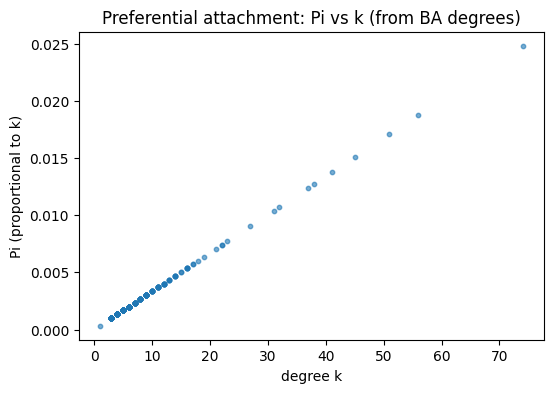

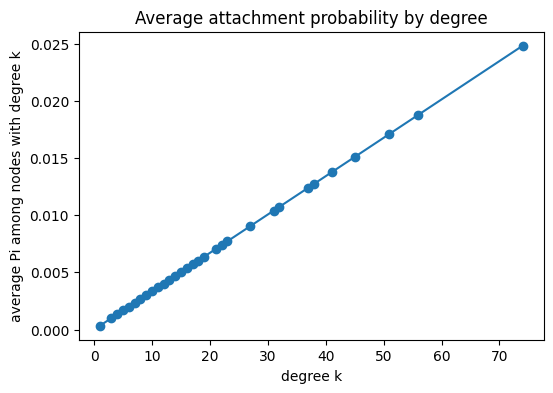

In [8]:
deg = degrees_list(G_ba)
total_degree = deg.sum()
pi = deg / total_degree  # attachment probability up to normalization

# Scatter: (degree, probability)
plt.figure(figsize=(6,4))
plt.scatter(deg, pi, s=10, alpha=0.6)
plt.xlabel("degree k")
plt.ylabel("Pi (proportional to k)")
plt.title("Preferential attachment: Pi vs k (from BA degrees)")
plt.show()

# Also show the average Pi for each degree k (smoother)
vals = np.unique(deg)
avg_pi = np.array([pi[deg == k].mean() for k in vals])

plt.figure(figsize=(6,4))
plt.plot(vals, avg_pi, "o-")
plt.xlabel("degree k")
plt.ylabel("average Pi among nodes with degree k")
plt.title("Average attachment probability by degree")
plt.show()


### Short answer (B1) — write 4–7 sentences

Explain why “rich get richer” emerges from \(\Pi(i) \propto k_i\).  
In your answer, mention:
- what degree represents in a network,
- why high-degree nodes get selected more often,
- how this creates hubs over time.

In a network, a node’s degree k is the number of edges it has, i.e., how many connections it currently has (a proxy for visibility/popularity). In the BA model, a new node attaches to an existing node i with probability \Pi(i)\propto k_i, so higher-degree nodes are selected more often. This creates positive feedback: being chosen increases a node’s degree, which then further increases its chance of being chosen again. Over time, a small number of nodes accumulate many more links than average, producing visible hubs and a heavy-tailed degree distribution. Hence the “rich get richer” effect emerges naturally from preferential attachment.  
在网络里，节点的度 k 表示它有多少条边，也就是它连接了多少个其他节点（“受欢迎/曝光度”）。在 BA 模型中，新节点连接到旧节点 i 的概率满足pi of i与ki成正比，所以度越大，被选中的概率越高。这会形成正反馈：一个节点因为度大更常被连到，于是它的度进一步增加；度增加后又更容易被选中。久而久之，少数早期或偶然占优的节点会不断累积连接，度远高于平均水平，逐渐形成明显的 hub。因此“富者愈富”并不是额外规则，而是从“按度比例选择”的机制自然涌现出来的。


## Part C — Implement a simple BA generator yourself (coding + understanding)

NetworkX gives you `barabasi_albert_graph`, but implementing a simplified version helps you understand the algorithm.

### Task C1
Implement a BA-style growth process:
1. Start with a small connected seed (often a complete graph of size `m`).
2. For each new node:
   - compute degrees of existing nodes
   - select `m` distinct targets with probability proportional to degree
   - connect the new node to those targets


Manual BA: mean degree = 5.976 max degree = 59


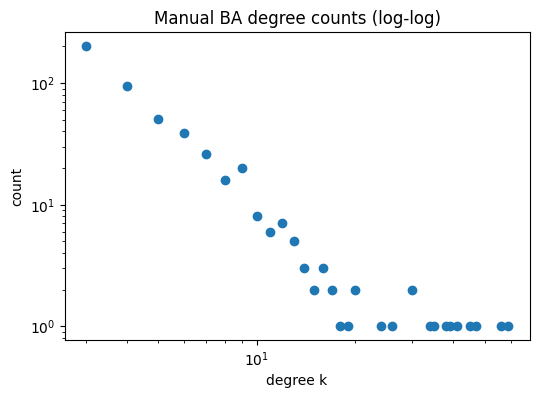

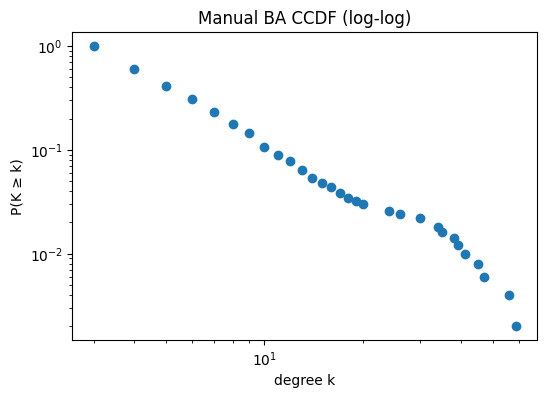

In [ ]:
def simple_ba(n, m, seed=0):
    rng = np.random.default_rng(seed)
    # Start with a complete graph on m nodes (connected and non-trivial degrees)
    G = nx.complete_graph(m) #创建随机数生成器（保证可复现）

    for new_node in range(m, n):
        G.add_node(new_node) #从编号 m 开始一直加到 n-1，总共让图最后有 n 个节点

        nodes = np.array(list(G.nodes())) #当前图里的所有节点
        deg = np.array([G.degree(v) for v in nodes], dtype=float) #每个节点的度

        probs = deg / deg.sum() #把度归一化成概率

        # choose m distinct targets based on probs
        targets = rng.choice(nodes, size=m, replace=False, p=probs)

        for t in targets: #把新节点和这些目标连边
            G.add_edge(new_node, int(t))

    return G

# 核心思路
# 从一个小图开始（你这里用的是 m 个点的完全图）， 每次加入一个新节点 new_node，让它连 m 条边到旧节点，连接旧节点的概率 与旧节点的度成正比（preferential attachment）

G_ba_manual = simple_ba(n=500, m=3, seed=1)
deg_manual = degrees_list(G_ba_manual)

print("Manual BA: mean degree =", deg_manual.mean(), "max degree =", deg_manual.max())
plot_degree_loglog_counts(deg_manual, title="Manual BA degree counts (log-log)")
ccdf_loglog(deg_manual, title="Manual BA CCDF (log-log)")


### Task C2 (small graph visualisation)
Create a small BA graph and draw it so you can *see* hubs.

> Keep `n_small` small (like 20–40), otherwise the plot gets messy.


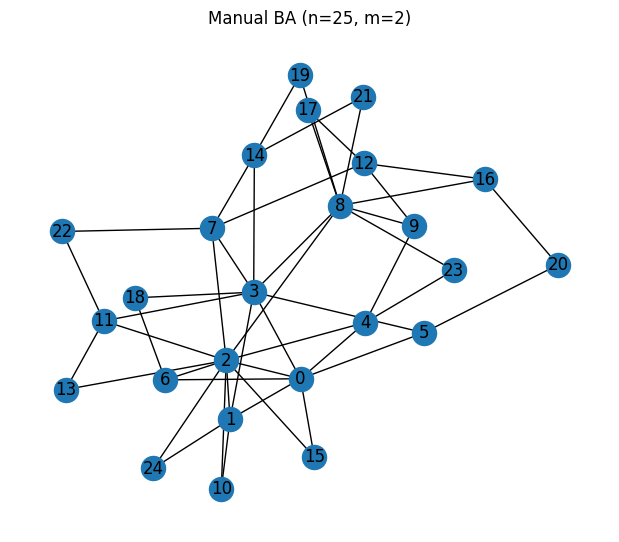

Degrees: [np.int64(7), np.int64(5), np.int64(11), np.int64(8), np.int64(4), np.int64(3), np.int64(3), np.int64(5), np.int64(8), np.int64(3), np.int64(2), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(2), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]
Max degree node(s): [2]


In [10]:
n_small = 25
m_small = 2

G_small = simple_ba(n_small, m_small, seed=2)
draw_graph_small(G_small, title=f"Manual BA (n={n_small}, m={m_small})", seed=2)

deg_s = degrees_list(G_small)
print("Degrees:", list(deg_s))
print("Max degree node(s):", [v for v, d in G_small.degree() if d == deg_s.max()])


### Short answer (C) — write 5–8 sentences

1. Why do we start from a complete graph (or another connected seed) instead of a single node?  
我们用完全图（或其他连通的 seed）开始，而不是从单个节点开始，是因为 BA 的优先连接概率pi(i)正比于ki 需要节点有非零度；如果一开始只有一个点或出现很多度为 0 的点，就会出现“没法按度分配概率/网络不连通或过于退化”的问题。  
We start from a complete graph (or another connected seed) rather than a single node because preferential attachment Pi(i) propto ki requires nonzero degrees; starting from a single node (or many zero-degree nodes) can make the probability rule ill-defined or lead to a degenerate/poorly connected initial structure.  

2. In your implementation, what happens if you set `replace=True` when choosing targets?  
replace=True 会允许同一个旧节点被抽中多次。由于这里是简单图（simple graph），重复加同一条边不会增加新边数，所以新节点实际连到的不同目标数可能少于 m，等价于“每步新增的独立边变少”，从而偏离标准 BA 的设定。  
With replace=True, the same existing node can be selected multiple times among the m targets. In a simple graph, duplicate edges do not create new distinct edges, so the new node may end up connecting to fewer than m distinct neighbours, deviating from the standard BA rule.

3. What part of the algorithm is responsible for hubs appearing?   
导致 hub 的关键是按度成比例抽样这一步：probs = deg / deg.sum() 再用 rng.choice(..., p=probs) 选择目标。度越大越容易被选中，度会进一步变大，形成“富者愈富”的正反馈，随着网络增长就自然长出 hub。  
Hubs arise from the degree-proportional sampling step: probs = deg / deg.sum() and then choosing targets with rng.choice(..., p=probs). High-degree nodes get selected more often, which increases their degree further, creating a rich-get-richer feedback that produces hubs over time.



## Part D — Nonlinear preferential attachment \(\Pi(k) \propto k^\alpha\) (harder)

Your lecture mentions that the attachment rule can be generalized:

\[
\Pi(i) \propto k_i^{\alpha}
\]

- If **\(\alpha < 1\)**: attachment is *sublinear* → hubs are weaker.
- If **\(\alpha = 1\)**: standard BA.
- If **\(\alpha > 1\)**: *superlinear* → can produce a “winner-takes-all” super-hub.

### Task D1
Implement a nonlinear BA generator and compare outcomes for different \(\alpha\).


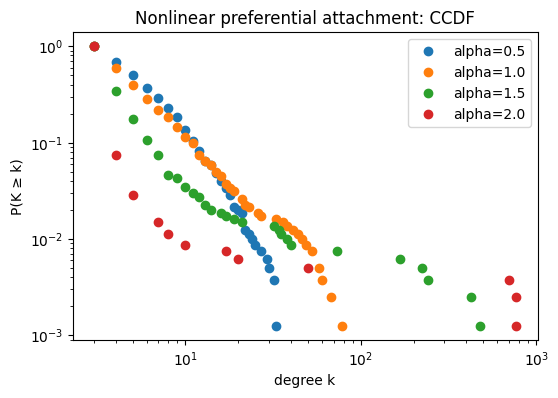

alpha=0.5: max degree ≈ 33
alpha=1.0: max degree ≈ 78
alpha=1.5: max degree ≈ 481
alpha=2.0: max degree ≈ 772


In [11]:
def nonlinear_ba(n, m, alpha=1.0, seed=0):
    rng = np.random.default_rng(seed)
    G = nx.complete_graph(m)

    for new_node in range(m, n):
        G.add_node(new_node)

        nodes = np.array(list(G.nodes()))
        deg = np.array([G.degree(v) for v in nodes], dtype=float)

        weights = deg ** alpha
        probs = weights / weights.sum()

        targets = rng.choice(nodes, size=m, replace=False, p=probs)
        for t in targets:
            G.add_edge(new_node, int(t))

    return G

n = 800
m = 3
alphas = [0.5, 1.0, 1.5, 2.0]

max_degs = []
plt.figure(figsize=(6,4))
for a in alphas:
    G = nonlinear_ba(n, m, alpha=a, seed=1)
    deg = degrees_list(G)
    max_degs.append(deg.max())
    # plot CCDF for each alpha
    vals, counts = np.unique(deg, return_counts=True)
    N = counts.sum()
    order = np.argsort(vals)
    vals = vals[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / N
    plt.loglog(vals, ccdf, "o", label=f"alpha={a}")

plt.xlabel("degree k")
plt.ylabel("P(K ≥ k)")
plt.title("Nonlinear preferential attachment: CCDF")
plt.legend()
plt.show()

for a, md in zip(alphas, max_degs):
    print(f"alpha={a}: max degree ≈ {md}")


### Task D2 (challenge)
For one value of \(\alpha\), compute a simple inequality measure of degrees: the **Gini coefficient**.

This is optional but helps quantify “hub dominance”.

> The Gini coefficient is 0 if all degrees are equal; closer to 1 means more unequal.


In [12]:
def gini(x):
    x = np.array(x, dtype=float)
    x = x[x >= 0]
    if x.size == 0:
        return np.nan
    if np.allclose(x.sum(), 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    cumx = np.cumsum(x)
    # Gini formula using cumulative sums
    g = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return g

# Pick one alpha to study
alpha = 2.0
G = nonlinear_ba(n=800, m=3, alpha=alpha, seed=2)
deg = degrees_list(G)

print("alpha =", alpha)
print("mean degree =", deg.mean())
print("max degree =", deg.max())
print("Gini(degree) =", round(gini(deg), 4))


alpha = 2.0
mean degree = 5.985
max degree = 741
Gini(degree) = 0.4952


### Short answer (D) — write 6–10 sentences

1. Describe what changes when \(\alpha\) increases from 0.5 → 2.0.  
alpha增大意味着“优先连接”的强度变大：从 pi(i)正比于k^0.5（偏好较弱）变成 pi(i)正比于k^2（偏好极强）。随着 alpha 上升，连接更集中到少数高阶节点，度分布的尾巴更长、更不均衡；在 log-log 的 CCDF 上通常会看到尾部更突出、最大度（max degree）更大，Gini(degree) 也更高。  
Increasing alpha strengthens preferential attachment: \Pi(i)\propto k^{0.5} is weak bias, while \Pi(i)\propto k^{2} is very strong bias toward high-degree nodes. As alpha rises, edges concentrate on fewer nodes, the tail becomes heavier/more unequal; on the log–log CCDF you typically see a more pronounced tail, a larger max degree, and a higher Gini(degree).

2. Explain why \(\alpha > 1\) can produce a “winner-takes-all” network.  
因为当 alpha>1 时，吸引力 k^alpha 是超线性的：度稍微大一点的节点，权重会被放大得更多，于是它被选中的概率会增长得更快。    
When alpha>1, attractiveness k^\alpha is superlinear, so small degree advantages are amplified disproportionately. This creates a stronger rich-get-richer feedback: a node that is slightly ahead becomes much more likely to receive new links, grows faster, and pulls away from others, potentially leading to condensation / winner-takes-all behavior.  

3. Which \(\alpha\) do you think is most realistic for social networks, and why?  
我认为社交网络里最现实的通常是 alpha约等于 1（或略小于 1）。人们确实更容易关注更受欢迎的人（存在优先连接），但同时也受圈层/同质性、共同好友、地理与兴趣、以及注意力上限等因素限制，不太可能达到 alpha=2 那种极端垄断。因此 alpha 在 1 附近更符合“有 hub 但不彻底赢家通吃”的现实特征。  
For social networks, alpha approx 1 (or slightly below 1) is often most realistic. Popularity matters (so preferential attachment exists), but community structure, homophily, shared friends, and limited attention constrain how extreme the concentration can become, making alpha=2 usually too monopolistic. Values near 1 match the common pattern of hubs without complete winner-takes-all domination.


## Part E — Copying model (alternative mechanism) (hard)

Your lecture also mentions link selection / copying ideas:
- A new node “copies” some links from an existing node (e.g., web pages copying reference lists).
- This can also produce heavy-tailed distributions.

### Task E1
Implement a very simple copying model:
1. Start with a small seed graph.
2. For each new node:
   - pick an existing “prototype” node uniformly at random
   - with probability `p_copy`, copy each of its neighbors as an edge
   - if we still have fewer than `m` edges, add random edges to reach `m`


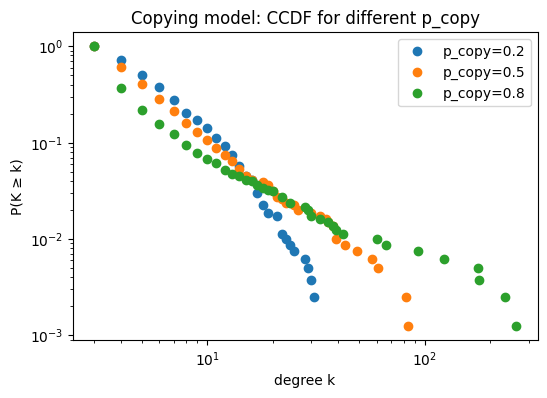

In [ ]:
# 目标：生成一个有 n 个节点的图。每次加入一个新节点时，它会：先随机挑一个“原型节点 prototype（proto）”
# 然后以概率 p_copy 复制这个 prototype 的邻居（朋友）
# 如果复制到的邻居不够 m 个，就随机补齐到 m 个
# 最后新节点连向这 m 个目标节点

def copying_model(n, m, p_copy=0.5, seed=0):
    rng = np.random.default_rng(seed)
    G = nx.complete_graph(m)

    for new_node in range(m, n):
        G.add_node(new_node)

        nodes = list(G.nodes())
        proto = int(rng.choice(nodes))  # prototype node
        neighbors = list(G.neighbors(proto))

        selected = []
        for nb in neighbors:
            if rng.random() < p_copy:
                selected.append(int(nb))

        # If too few copied links, add random nodes (avoid self-loops and duplicates)
        while len(selected) < m:
            candidate = int(rng.choice(nodes))
            if candidate != new_node and candidate not in selected:
                selected.append(candidate)

        # Keep exactly m targets
        selected = selected[:m]
        for t in selected:
            if t != new_node:
                G.add_edge(new_node, t)

    return G

n = 800
m = 3
p_list = [0.2, 0.5, 0.8]

plt.figure(figsize=(6,4))
for p_copy in p_list:
    Gc = copying_model(n, m, p_copy=p_copy, seed=1)
    deg = degrees_list(Gc)
    # CCDF
    vals, counts = np.unique(deg, return_counts=True)
    N = counts.sum()
    order = np.argsort(vals)
    vals = vals[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / N
    plt.loglog(vals, ccdf, "o", label=f"p_copy={p_copy}")

plt.xlabel("degree k")
plt.ylabel("P(K ≥ k)")
plt.title("Copying model: CCDF for different p_copy")
plt.legend()
plt.show()


### Short answer (E) — write 6–10 sentences

1. How does increasing `p_copy` change the tail of the distribution?  
p_copy 越大，新节点越倾向于复制 prototype 的邻居，从而更容易继承/放大已有的连接模式。结果是度分布会变得更重尾（heavier tail）：高阶节点更容易出现，CCDF 的尾部下降更慢、延伸到更大的 k。p_copy 较小（比如 0.2）时复制弱，更多是随机补齐链接，尾巴更短、更接近“随机图”那种不太极端的情况。  
As p_copy increases, new nodes copy more of the prototype’s neighbors, which reinforces existing connectivity patterns. This typically produces a heavier tail: more high-degree nodes, and a CCDF tail that decays more slowly and extends to larger k. With smaller p_copy (e.g., 0.2), copying is weaker and more links are filled in randomly, giving a shorter tail closer to a random-like network.  

2. Compare copying vs preferential attachment: what is similar, and what is different?  
相同点：两者都能产生“富者愈富”的效果（即使 copying 没有直接写 \Pi(i)\propto k_i），因为高阶节点更常出现在别人的邻居里，被复制到的机会也更大，所以也会长出 hub、出现长尾。
不同点：Preferential attachment 是直接按度选节点（概率显式与 k 成比例或 k^\alpha）；Copying 是先选一个 prototype 再复制它的邻居，偏好来自“网络局部结构/邻居集合”的复制，而不是直接看全网度。Copying 还更自然地引入“共同邻居/三角闭合”（你复制同一个人的朋友，很容易形成三角形）。  
Similarity: both mechanisms can generate hubs/heavy tails, and copying can implicitly create a rich-get-richer effect because high-degree nodes appear in many neighborhoods and thus get copied more often.
Difference: preferential attachment directly samples nodes by degree (explicit \Pi(i)\propto k_i or k_i^\alpha), while copying chooses a prototype and then copies its neighbors, so the bias comes from local neighborhood structure rather than global degree. Copying also naturally encourages shared neighbors/triadic closure.  

3. Give one real-world example where copying might be a more realistic mechanism than “rich-get-richer”.  
一个典型例子是社交平台的新用户关注行为：新用户往往先点进某个“参考账号/朋友/网红”，然后直接照着它的关注列表去关注一批人（“抄作业”式关注），这更像 copying，而不是新用户先统计全网谁度最高再按度概率去连。类似地，网页/博客也会“参考一个模板站点”，复制它的外链/友情链接列表。   
A common real-world example is follow recommendations for new users on social platforms: a user picks a prototype account (a friend/celebrity) and then follows many of the same accounts (“copying the follow list”). That is often more realistic than assuming the user explicitly attaches based on global degree. Similarly, websites/blogs may copy link lists or blogrolls from a template/reference site.


## Part F — (Optional) Rough exponent estimation (very optional, reflective)

**Warning:** Estimating power-law exponents properly is non-trivial.  
Here we do a *rough* check using a log–log linear fit on the CCDF tail.

### Task F1
Pick a BA-like network and fit a line to the tail of log(CCDF) vs log(k).

> Do not over-interpret the result. This is for intuition only.


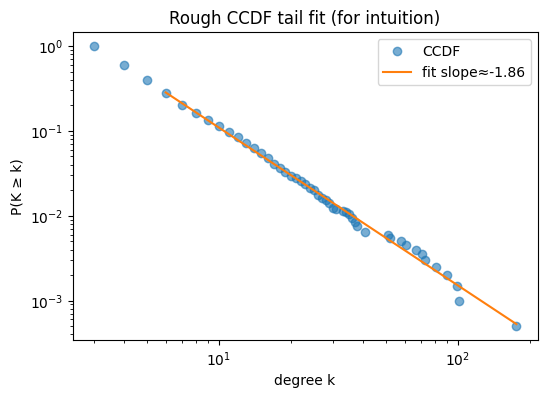

Rough slope (CCDF) a ≈ -1.861
Note: For a power-law PDF with exponent gamma, CCDF slope is approximately -(gamma-1).


In [14]:
def rough_ccdf_tail_slope(deg, k_min=5):
    vals, counts = np.unique(deg, return_counts=True)
    N = counts.sum()
    order = np.argsort(vals)
    vals = vals[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / N

    # Tail selection
    mask = vals >= k_min
    x = np.log(vals[mask])
    y = np.log(ccdf[mask])

    if x.size < 2:
        return np.nan

    # Linear fit: y = a x + b
    a, b = np.polyfit(x, y, 1)
    return a, b, vals, ccdf, mask

G = nx.barabasi_albert_graph(2000, 3, seed=0)
deg = degrees_list(G)

a, b, vals, ccdf, mask = rough_ccdf_tail_slope(deg, k_min=6)

plt.figure(figsize=(6,4))
plt.loglog(vals, ccdf, "o", alpha=0.6, label="CCDF")
# plot fitted line on tail
x_tail = np.log(vals[mask])
y_fit = a * x_tail + b
plt.loglog(vals[mask], np.exp(y_fit), "-", label=f"fit slope≈{a:.2f}")
plt.xlabel("degree k")
plt.ylabel("P(K ≥ k)")
plt.title("Rough CCDF tail fit (for intuition)")
plt.legend()
plt.show()

print("Rough slope (CCDF) a ≈", round(a, 3))
print("Note: For a power-law PDF with exponent gamma, CCDF slope is approximately -(gamma-1).")


## Wrap-up reflection (5–10 min)

Write 6–10 sentences reflecting on:

1. Which mechanism(s) in this lab could plausibly generate real-world networks (web, citations, social)?
2. What *limitations* do these models have (e.g., direction, weights, node/edge deletion, communities)?
3. If you were to improve the BA model for a real dataset, what would you add?

---
**End of lab**
